In [1]:
from scipy import datasets
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

dataDirectory = '/home/dave/SCRAM/data/'
sourceDirectory = '/home/dave/SCRAM/delfic_output/'
outputShape = (512, 512)

# find the names of each dataset. There are 3 files for each dataset *_X.npy, *_Yd.npy, *_Yr.npy
def getDatasetNames(dataDirectory):
    import os
    files = os.listdir(dataDirectory)
    datasets = set()
    for f in files:
        if f.endswith('_X.npy'):
            datasets.add(f[:-6])

    return list(datasets)

datasets = getDatasetNames(dataDirectory)
print(f"{len(datasets)} Datasets found")

# load a dataset
def loadDataset(name, dataDirectory):
    X = np.load(dataDirectory + name + '_X.npy')
    Yd = np.load(dataDirectory + name + '_Yd.npy')
    Yr = np.load(dataDirectory + name + '_Yr.npy')

    #swap the axes to match the expected shape
    X = np.swapaxes(X, 1, 2)
    Yd = np.swapaxes(Yd, 1, 2)

    return X, Yd, Yr

# load a dataset
X, Yd, Yr = loadDataset(datasets[0], dataDirectory)
print(f"Dataset {datasets[0]} loaded with {X.shape[0]} samples")

# reserve memory for the X, Yd, Yr arrays of all datasets
nDatasets = len(datasets)
nSamples = X.shape[0]
nTimesteps = X.shape[1]
nDetectors = X.shape[2]
nFeatures = X.shape[3]
print(f"nDatasets: {nDatasets}, nSamples: {nSamples}, nTimesteps: {nTimesteps}, nDetectors: {nDetectors}, nFeatures: {nFeatures}")
X = np.zeros((nDatasets * nSamples, nTimesteps, nDetectors, nFeatures), dtype=np.float32) #(x, y, dr, Dose, dDose)
Yd = np.zeros((nDatasets * nSamples, nTimesteps, nDetectors), dtype=np.float32) #true dose
Yr = np.zeros((nDatasets * nSamples, nDetectors, 2), dtype=np.float32) #true position
Ysource = {}

#print the shape and expected size of the arrays
print(f"X: {X.shape}, {X.size * X.itemsize / 1e9} GB")
print(f"Yd: {Yd.shape}, {Yd.size * Yd.itemsize / 1e9} GB")
print(f"Yr: {Yr.shape}, {Yr.size * Yr.itemsize / 1e9} GB")

for i, dataset in enumerate(datasets):
    _X, _Yd, _Yr = loadDataset(dataset, dataDirectory)
    X[i * nSamples:(i + 1) * nSamples] = _X
    Yd[i * nSamples:(i + 1) * nSamples] = _Yd
    Yr[i * nSamples:(i + 1) * nSamples] = _Yr
    #for the next nSamples, associate the index to the dataset name
    for j in range(nSamples):
        Ysource[i * nSamples + j] = dataset

print(f"Datasets loaded into arrays")


160 Datasets found
Dataset Y10H0SS6DS280SA19BA4000 loaded with 20 samples
nDatasets: 160, nSamples: 20, nTimesteps: 93, nDetectors: 240, nFeatures: 5
X: (3200, 93, 240, 5), 1.42848 GB
Yd: (3200, 93, 240), 0.285696 GB
Yr: (3200, 240, 2), 0.006144 GB
Datasets loaded into arrays


In [2]:
source = 'Y30H8SS3DS19SA24BA5022'
#the source string includes metadata that is an input to the model
# YaHbSScDSdSAeBAf -> a:f may be 1 or multiple characters
# a: yield
# b: height of burst
# c: surface wind speed
# d: surface wind direction
# e: winds aloft speed
# f: winds aloft altitude

#parse the string
def parseSourceMetaData(source):
    source = source.split('Y')[1]
    yield_ = int(source.split('H')[0])
    source = source.split('H')[1]
    height = int(source.split('SS')[0])
    source = source.split('SS')[1]
    surface_speed = int(source.split('DS')[0])
    source = source.split('DS')[1]
    surface_direction = int(source.split('SA')[0])
    source = source.split('SA')[1]
    aloft_speed = int(source.split('BA')[0])
    source = source.split('BA')[1]
    aloft_altitude = int(source)

    return np.array([yield_, height, surface_speed, surface_direction, aloft_speed, aloft_altitude], dtype=np.float32)

metaData = parseSourceMetaData(source)
print(metaData)

[3.000e+01 8.000e+00 3.000e+00 1.900e+01 2.400e+01 5.022e+03]


In [3]:
# now that the X data is loaded into ram, create a dataloader
# when returning a batch, return a subset of the data, this will require loading 
# the Y data from disk, but this is because of the volume of Y data

class Dataset(torch.utils.data.Dataset):
  def __init__(self, X, Yd, Yr, Ysource):
      self.X = X
      self.Yd = Yd
      self.Yr = Yr
      self.Ysource = Ysource

  def __len__(self):
      return self.X.shape[0]

  def __getitem__(self, index):
      Y = np.load(sourceDirectory + Ysource[index] + f'/{Ysource[index]}.pkl', allow_pickle=True)
      Y = np.array(Y, dtype=np.float32)
      
      return self.X[index], parseSourceMetaData(Ysource[index]), self.Yd[index], self.Yr[index], Y
  
dataset = Dataset(X, Yd, Yr, Ysource)

# create a dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True) 

# test the dataloader
for i, data in enumerate(dataloader):
    X, metadata, Yd, Yr, Y = data
    print(f"Batch {i}, X: {X.shape}, Yd: {Yd.shape}, Yr: {Yr.shape}, Y: {Y.shape}")
    break

Batch 0, X: torch.Size([4, 93, 240, 5]), Yd: torch.Size([4, 93, 240]), Yr: torch.Size([4, 240, 2]), Y: torch.Size([4, 93, 512, 512])


In [9]:
# build a GRU to image model. The input data is provided by a series of detectors, each with 5 features. The output is a series of 512x512 images 
# reconstruct a decaying radiation field. The model will also take metadata as input, the metadata will be concatenated to the output of the GRU, it 
# is static information that is relevant to the entire sequence. The metadata will be used to predict the location and strength of the radiation field.

# Since the output is an image, the model will be a convolutional neural network. The GRU will be used to process the input data and the metadata will be concatenated


class RadiationGRUDeconv(nn.Module):
    def __init__(self, nDetectors, nFeatures, nTimesteps, nMetadata):
        super(RadiationGRUDeconv, self).__init__()
        self.nDetectors = nDetectors
        self.nFeatures = nFeatures
        self.nTimesteps = nTimesteps
        self.nMetadata = nMetadata

        # GRU
        inputSize = nDetectors * nFeatures + nMetadata
        self.hiddenSize = 512
        self.nLayers = 2
        self.gru = nn.GRU(inputSize, self.hiddenSize, self.nLayers, batch_first=True)

        # Fully connected layer to process the GRU output
        self.fc = nn.Linear(self.hiddenSize, 256 * 16 * 16)

        # Deconvolutional layers resulting in a 512x512 image
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, detectorData, metaData, h):
        # detectorData: (batch_size, sequence_length, nDetectors * 5)
        # metaData: (batch_size, sequence_length, 6)
        batch_size = detectorData.size(0)

        # Reshape the detector data to (batch_size, sequence_length, nDetectors * nFeatures)
        detectorData = detectorData.view(batch_size, self.nTimesteps, -1)
        #print(f"Detector data shape: {detector_data.shape}") # -> Detector data shape: torch.Size([8, 93, 1200])

        # reshape the constant metadata from a 1d tensor to a 3d tensor
        metaData = metaData.unsqueeze(1).repeat(1, self.nTimesteps, 1)
        #print(f"Metadata shape: {metaData.shape}") # -> Metadata shape: torch.Size([8, 93, 6])

        x = torch.cat((detectorData, metaData), -1)  # (batch_size, sequence_length, nDetectors * nFeatures + 6)
        #print(f"Combined data shape: {x.shape}") # -> Combined data shape: torch.Size([8, 93, 1206])
        
        # Pass through the GRU
        out, h = self.gru(x, h)  # out: (batch_size, seq_length, hidden_size)

        # Prepare a list to hold the images for each timestep
        images = []

        # Process each timestep's output to generate a 512x512 image
        for t in range(self.nTimesteps):
            timestep_out = self.fc(out[:, t, :])  # Process each timestep
            timestep_out = timestep_out.view(batch_size, 256, 16, 16)  # Reshape to a 16x16 feature map with 256 channels
            image = self.deconv(timestep_out)  # Reconstruct the 512x512 image
            images.append(image)

        # Stack the images along a new dimension representing time
        images = torch.stack(images, dim=1)  # (batch_size, nTimesteps, 1, 512, 512) -> 1 is the number of color channels
        images = images.squeeze(2)  # (batch_size, nTimesteps, 512, 512)

        return images, h

    def init_hidden(self, batch_size):
        # Initialize hidden state with zeros
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        return torch.zeros(self.nLayers, batch_size, self.hiddenSize).to(device)
    
# create the model
model = RadiationGRUDeconv(nDetectors, nFeatures, nTimesteps, 6)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

h0 = model.init_hidden(8)



In [ ]:
# test the model
for i, data in enumerate(dataloader):
    X, metadata, Yd, Yr, Y = data
    X = X.to(device)
    metadata = metadata.to(device)
    output, h0 = model(X, metadata, h0)
    print(f"Output shape: {output.shape}")
    print(f'Expected shape: {Y.shape}')
    break

In [8]:
def normalize_dose_features(X):
    # Assuming X has shape (batch_size, nTimesteps, nDetectors, 5)
    # Extract features
    x_position = X[..., 0]  # x_position (shape: (batch_size, nTimesteps, nDetectors))
    y_position = X[..., 1]  # y_position (shape: (batch_size, nTimesteps, nDetectors))
    position_error = X[..., 2]  # position_error (shape: (batch_size, nTimesteps, nDetectors))
    dose_rate = X[..., 3]  # Dose_rate (shape: (batch_size, nTimesteps, nDetectors))
    dose_rate_error = X[..., 4]  # Dose_rate_error (shape: (batch_size, nTimesteps, nDetectors))

    # if an dose rate values are negative, set them to 0
    dose_rate[dose_rate < 0] = 0

    # Check for negative values
    if (dose_rate < 0).any():
        raise ValueError('Dose rate must be non-negative')
    
    if (dose_rate_error < 0).any():
        raise ValueError('Dose rate error must be non-negative')
    
    # Normalize x_position and y_position to [0, 1]
    x_position_normalized = x_position / 50.0
    y_position_normalized = y_position / 50.0
    position_error_normalized = position_error / 50.0
    
    # Apply logarithmic transformation
    dose_rate_log = torch.log1p(dose_rate)
    dose_rate_error_log = torch.log1p(dose_rate_error)
    
    # Reassemble the data
    # Keep X_position, Y_position, and position_error unchanged
    X_normalized = X.clone()  # Create a copy to avoid in-place modifications
    X_normalized[..., 0] = x_position_normalized
    X_normalized[..., 1] = y_position_normalized
    X_normalized[..., 2] = position_error_normalized
    X_normalized[..., 3] = dose_rate_log
    X_normalized[..., 4] = dose_rate_error_log
    
    return X_normalized

def log_normalize_image(Y, epsilon=1e-6):
    # Assuming Y has shape (batch_size, nTimesteps, x, y)
    batch_size, nTimesteps, x, y = Y.shape
    
    Y_log = torch.log1p(Y)  # Log transform with a small constant
    # Find min and max along spatial dimensions (x, y) for each timestep
    Y_min = Y_log.min(dim=3, keepdim=True)[0].min(dim=2, keepdim=True)[0]  # Shape: (batch_size, nTimesteps, 1, 1)
    Y_max = Y_log.max(dim=3, keepdim=True)[0].max(dim=2, keepdim=True)[0]  # Shape: (batch_size, nTimesteps, 1, 1)
    
    
    # Normalize to [0, 1]
    Y_normalized = (Y_log - Y_min) / (Y_max - Y_min + epsilon)  # Add epsilon to avoid division by zero
    
    return Y_normalized

In [31]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
n_epochs = 10
accumulation_steps = 10  # Adjust as needed

model.train()

for epoch in range(n_epochs):
    for i, data in enumerate(dataloader):
        X, metaData, Yd, Yr, Y = data
        X = X.to(device)  # (batch_size, nTimesteps, nDetectors * nFeatures)
        metaData = metaData.to(device)  # (batch_size, nMetadata)
        Y = Y.to(device)  # (batch_size, nTimesteps, 512, 512)

        # check for nan values
        if torch.isnan(X).any():
            print("X has NaN values before normalization")
            break

        # do log normalization to the X data along the 4th and 5th axis
        X = normalize_dose_features(X)

        # do log normalization to the Y data
        Y = log_normalize_image(Y)

        # Initialize hidden state
        batch_size = X.size(0)
        h0 = model.init_hidden(batch_size).to(device)

        # check for nan values
        if torch.isnan(X).any():
            print("X has NaN values")
            break
        if torch.isnan(metaData).any():
            print("metadata has NaN values")
            break
        if torch.isnan(Y).any():
            print("Y has NaN values")
            break

        # Forward pass
        output, h0 = model(X, metaData, h0)  # (batch_size, nTimesteps, 512, 512)

        # Compute loss
        loss = criterion(output, Y)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        if i % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
            print(f'Epoch {epoch}, Batch {i}, Loss: {loss.item()}')

    print(f'Epoch {epoch}, Loss: {loss.item()}')


Epoch 0, Batch 0, Loss: 0.012626981362700462
Epoch 0, Batch 10, Loss: 0.011367995291948318
Epoch 0, Batch 20, Loss: 0.01395568810403347
Epoch 0, Batch 30, Loss: 0.0067115165293216705
Epoch 0, Batch 40, Loss: 0.015082682482898235
Epoch 0, Batch 50, Loss: 0.020061954855918884
Epoch 0, Batch 60, Loss: 0.008276165463030338
Epoch 0, Batch 70, Loss: 0.014951326884329319
Epoch 0, Batch 80, Loss: 0.005021183285862207
Epoch 0, Batch 90, Loss: 0.005478177685290575
Epoch 0, Batch 100, Loss: 0.01820022240281105
Epoch 0, Batch 110, Loss: 0.013413375243544579
Epoch 0, Batch 120, Loss: 0.0101627167314291
Epoch 0, Batch 130, Loss: 0.01849476993083954
Epoch 0, Batch 140, Loss: 0.0157147403806448
Epoch 0, Batch 150, Loss: 0.010773440822958946
Epoch 0, Batch 160, Loss: 0.008466347120702267
Epoch 0, Batch 170, Loss: 0.012472587637603283
Epoch 0, Batch 180, Loss: 0.012867484241724014
Epoch 0, Batch 190, Loss: 0.014941539615392685
Epoch 0, Batch 200, Loss: 0.014629838056862354
Epoch 0, Batch 210, Loss: 0.00

KeyboardInterrupt: 

In [ ]:
# build a GRU model that takes in the X, Y, dR, Dose, dDose for each detector and then reconstructs the field at each time step
# at each timestep, the output is a 2d array of radiation exposure rate. The field is expected to decay over time. 
# the output image is 512x512

#the array also includes metadata that is an input to the model, but it is not injected until after the GRU layer

class GRUReconstructionModel(nn.Module):
    def __init__(self, nDetectors, nDetFeatures, nMetaDataFeatures, hidden_dim, output_height, output_width, num_layers=1):
        super(GRUReconstructionModel, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.nDetectors = nDetectors
        self.nDetFeatures = nDetFeatures
        self.nMetaDataFeatures = nMetaDataFeatures
        self.output_height = output_height
        self.output_width = output_width
        self.num_layers = num_layers
        
        # Define GRU layer
        input_size = nDetectors * nDetFeatures
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)

        # Define a hidden fully connected layer
        self.hidden_fc = nn.Linear(hidden_dim*2, 256)
        
        # Fully connected layer to map GRU output to image size
        self.fc = nn.Linear(256, output_height * output_width)

        # Define additional fully connected layer for metadata
        self.fc_metadata = nn.Linear(nMetaDataFeatures, hidden_dim)
        
    def forward(self, x, metadata):
        batch_size = x.size(0)  # Get batch size
        
        # Reshape input from (batch_size, nTimeSteps, nDetectors, nFeatures) to (batch_size, nTimeSteps, nDetectors * nFeatures)
        x = x.contiguous().view(batch_size, x.size(1), -1)
        
        # Initialize hidden state for GRU
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        
        # Pass data through GRU
        gru_out, _ = self.gru(x, h0)  # gru_out: [batch_size, timesteps, hidden_dim]
        
        # Process metadata through a linear layer
        metadata_processed = self.fc_metadata(metadata).unsqueeze(1)  # [batch_size, 1, hidden_dim]
        
        # Repeat metadata for each timestep
        metadata_repeated = metadata_processed.expand(-1, gru_out.size(1), -1)  # [batch_size, timesteps, hidden_dim]
        
        # Concatenate GRU output with metadata
        combined = torch.cat((gru_out, metadata_repeated), dim=-1)  # [batch_size, timesteps, hidden_dim * 2]

        # Pass through hidden fully connected layer
        combined = self.hidden_fc(combined)
        
        # Reconstruct the image for each timestep
        images = self.fc(combined)  # [batch_size, timesteps, output_height * output_width]

        # The images are always positive, so apply a ReLU activation
        images = nn.functional.relu(images)
        images = images.view(batch_size, x.size(1), self.output_height, self.output_width)  # [batch_size, timesteps, H, W]
        
        return images
    
model = GRUReconstructionModel(nDetectors=nDetectors, nDetFeatures=nFeatures, nMetaDataFeatures=6,
                               hidden_dim=128, output_height=512, 
                               output_width=512, num_layers=2)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Forward pass to confirm the model works
for i, data in enumerate(dataloader):
    X, metadata, Yd, Yr, Y = data
    X = X.to(device)
    metadata = metadata.to(device)
    output = model(X, metadata)
    print(f"Output shape: {output.shape}")
    print(f'Expected shape: {Y.shape}')
    break

In [ ]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
n_epochs = 10
accumulation_steps = 10  # Adjust as needed

for epoch in range(n_epochs):
    for i, data in enumerate(dataloader):
      X, metaData, Yd, Yr, Y = data
      X = X.to(device)
      metaData = metaData.to(device)
      Y = Y.to(device)
      
      # Forward pass
      output = model(X, metaData)
      loss = criterion(output, Y)
        
      # Backward pass
      loss.backward()
            
      if i % accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()
        print(f'Epoch {epoch}, Batch {i}, Loss: {loss.item()}')
            
    print(f'Epoch {epoch}, Loss: {loss.item()}')

In [11]:
# load the model
model = RadiationGRUDeconv(nDetectors, nFeatures, nTimesteps, 6)
model.load_state_dict(torch.load('model.pth'))
model.eval()
model.to(device)

RadiationGRUDeconv(
  (gru): GRU(1206, 512, num_layers=2, batch_first=True)
  (fc): Linear(in_features=512, out_features=65536, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): Sigmoid()
  )
)

Output shape: torch.Size([4, 93, 512, 512])
Expected shape: torch.Size([4, 93, 512, 512])


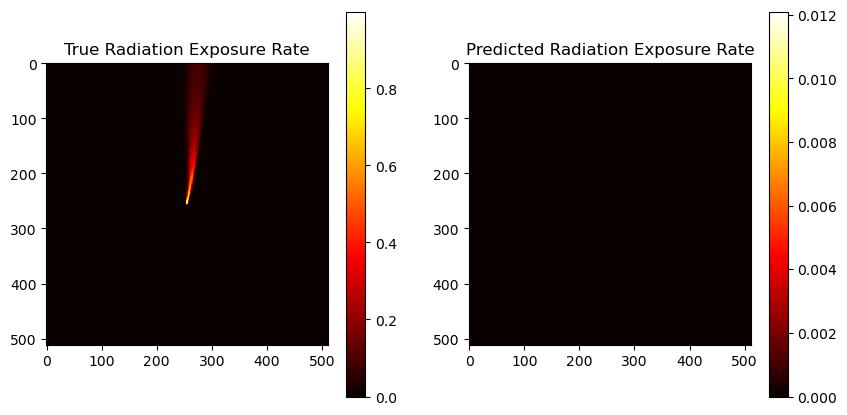

In [37]:
# do a forward pass on the model to get the output
for i, data in enumerate(dataloader):
  X, metaData, Yd, Yr, Y = data
  break

X = X.to(device)
metaData = metaData.to(device)

# normalize the X data
X = normalize_dose_features(X)

# normalize the Y data
Y = log_normalize_image(Y)

# initialize the hidden state
batch_size = X.size(0)
h0 = model.init_hidden(batch_size).to(device)

output, h0 = model(X, metaData, h0)

print(f'Output shape: {output.shape}')
print(f'Expected shape: {Y.shape}')

sample = 0
timestep = np.random.randint(0, nTimesteps)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(Y[sample, timestep].cpu().numpy(), cmap='hot', interpolation='nearest')
plt.title('True Radiation Exposure Rate')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(output[sample, timestep].detach().cpu().numpy(), cmap='hot', interpolation='nearest')
plt.title('Predicted Radiation Exposure Rate')
plt.colorbar()

plt.show()


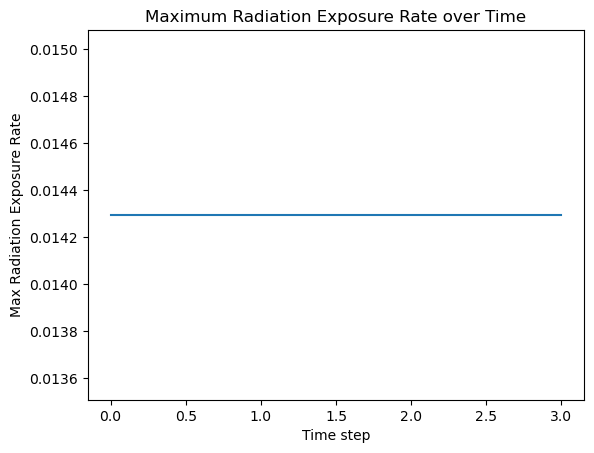

In [39]:
# create a plot that shows the max value from the output across all timesteps
max_values = output.max(dim=1)[0].cpu().detach().numpy()
# at each timestep find the max value, regradless of the position
max_values = max_values.max(axis=(1, 2))
plt.plot(max_values)
plt.xlabel('Time step')
plt.ylabel('Max Radiation Exposure Rate')
plt.title('Maximum Radiation Exposure Rate over Time')
plt.show()

In [32]:
#save the model
torch.save(model.state_dict(), 'model.pth')